In [73]:
"""
3-DOF Leg Workspace
Kai De La Cruz 6/27/2025
Converted from MATLAB to Python
"""

import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# DH Transform Function
# --------------------------
def transform(theta, d, a, alpha):
    """
    Generate a 4x4 homogeneous transform matrix using DH parameters
    Angles in radians
    """
    return np.array([
        [np.cos(theta), -np.sin(theta)*np.cos(alpha),  np.sin(theta)*np.sin(alpha), a*np.cos(theta)],
        [np.sin(theta),  np.cos(theta)*np.cos(alpha), -np.cos(theta)*np.sin(alpha), a*np.sin(theta)],
        [0,              np.sin(alpha),                np.cos(alpha),               d],
        [0,              0,                            0,                           1]
    ])


In [74]:
# ==========================
# 3-DOF Workspace
# ==========================
L1 = 2.285   # [in]
L2 = 4.77  
L3 = 5.75  
L4 = 6.125 

theta1_range = np.deg2rad(np.arange(-90, 90, 25))
theta2_range = np.deg2rad(np.arange(-180, 181, 25))
theta3_range = np.deg2rad(np.arange(0, 136, 25))

all_points = []

for th1 in theta1_range:
    for th2 in theta2_range:
        for th3 in theta3_range:

            A0 = transform(+np.pi/2, 0, 0, +np.pi/2)
            A1 = transform(th1 - np.pi/2, L1, 0, -np.pi/2)
            A2 = transform(th2 - np.pi/2, L2, L3, 0)
            A3 = transform(th3, 0, L4, 0)

            T = A0 @ A1 @ A2 @ A3

            all_points.append(T[0:3, 3])

all_points = np.array(all_points)


# ==========================
# 2-DOF Workspace
# ==========================
L3_2d = 5.372 
L4_2d = 6.125 

theta2_range2 = np.deg2rad(np.arange(0, 361, 10))
theta3_range2 = np.deg2rad(np.arange(0, 136, 10))

all_points2 = []

for th2 in theta2_range2:
    for th3 in theta3_range2:

        A0 = transform(+np.pi/2, 0, 0, +np.pi/2)
        A1 = transform(-np.pi/2, 0, 0, -np.pi/2)
        A2 = transform(th2 - np.pi/2, 0, L3_2d, 0)
        A3 = transform(th3, 0, L4_2d, 0)

        T = A0 @ A1 @ A2 @ A3

        all_points2.append(T[0:3, 3])

all_points2 = np.array(all_points2)


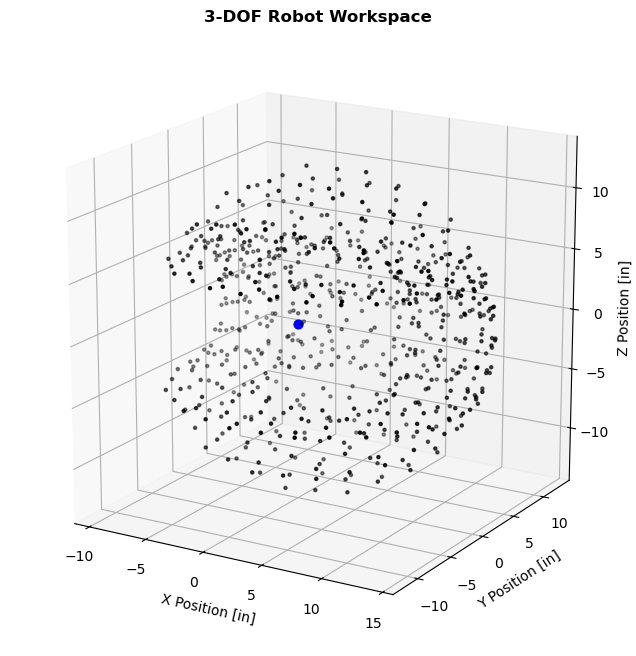

In [75]:
# ==========================
# Plot 3-DOF Workspace
# ==========================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(all_points[:,0], all_points[:,1], all_points[:,2],
           c='k', s=5, label='3-DOF Workspace')

ax.scatter(0, 0, 0, c='b', s=40, marker='o')

ax.set_xlabel('X Position [in]')
ax.set_ylabel('Y Position [in]')
ax.set_zlabel('Z Position [in]')
ax.set_title('3-DOF Robot Workspace',fontsize=12, fontweight='semibold')

ax.set_box_aspect([1,1,1])
ax.view_init(elev=17.5, azim=-59.08)
ax.grid(True)

plt.show()



In [76]:
# ==========================
# Alpha-shape surface reconstruction (captures concavities/void shells)
# ==========================
from scipy.spatial import Delaunay, cKDTree

def estimate_alpha(points_xyz, k=8, factor=2.2):
    """Heuristic alpha based on local point spacing."""
    tree = cKDTree(points_xyz)
    dists, _ = tree.query(points_xyz, k=k+1)
    spacing = np.median(dists[:, -1])
    return factor * spacing

def _tetra_circumradius(tetra_pts):
    """Return circumradius for one tetrahedron (4x3 array)."""
    p0 = tetra_pts[0]
    A = 2.0 * (tetra_pts[1:] - p0)
    b = np.sum(tetra_pts[1:]**2, axis=1) - np.sum(p0**2)
    try:
        center = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.inf
    return np.linalg.norm(center - p0)

def alpha_shape_3d(points_xyz, alpha):
    """
    Build a 3D alpha-shape boundary mesh from point cloud.
    Returns (vertices, faces) where faces are Nx3 vertex indices.
    """
    tri = Delaunay(points_xyz)
    simplices = tri.simplices

    keep = []
    for i, tet in enumerate(simplices):
        r = _tetra_circumradius(points_xyz[tet])
        if r < alpha:
            keep.append(i)

    if not keep:
        raise ValueError('No tetrahedra kept. Increase alpha.')

    kept = simplices[np.array(keep)]

    all_faces = np.vstack([
        kept[:, [0, 1, 2]],
        kept[:, [0, 1, 3]],
        kept[:, [0, 2, 3]],
        kept[:, [1, 2, 3]],
    ])

    faces_sorted = np.sort(all_faces, axis=1)
    unique_faces, counts = np.unique(faces_sorted, axis=0, return_counts=True)
    boundary_faces = unique_faces[counts == 1]

    return points_xyz, boundary_faces


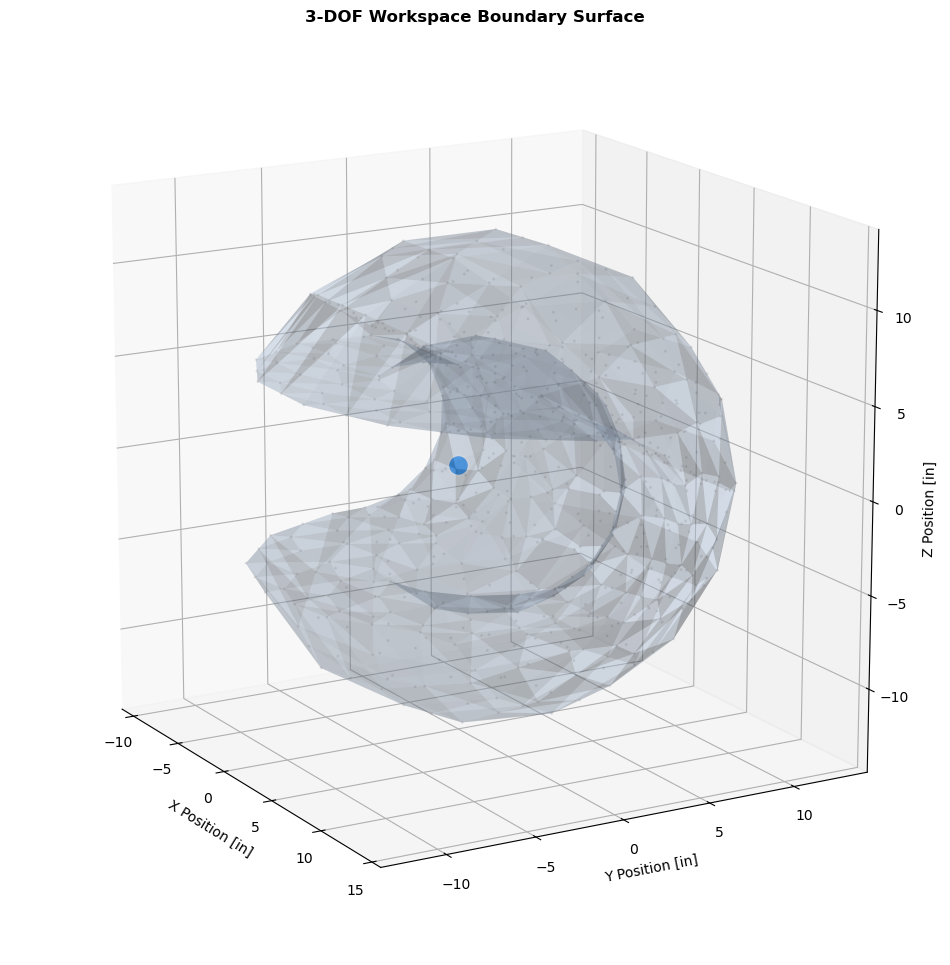

Boundary mesh faces: 840
Tip: reduce factor in estimate_alpha(...) for more cavity detail, increase for smoother shell.


In [88]:
# Reconstruct and plot smooth-ish workspace shell
alpha = estimate_alpha(all_points, k=8, factor=1.8)
verts, faces = alpha_shape_3d(all_points, alpha=alpha)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

mesh = ax.plot_trisurf(
    verts[:, 0], verts[:, 1], verts[:, 2],
    triangles=faces,
    color='lightsteelblue',
    alpha=0.25,
    linewidth=0.1,
    edgecolor='none'
)

# Optional: lightly overlay samples for context
ax.scatter(all_points[:, 0], all_points[:, 1], all_points[:, 2],
           s=1.5, c='k', alpha=0.05)

# Origin marker
ax.scatter(0, 0, 0, c='dodgerblue', s=220, marker='o', edgecolors='white', linewidths=1.5, label='Origin', depthshade=False, zorder=10)
# ax.text(0, 0, 0, '  Origin', color='dodgerblue', fontsize=10)

ax.set_xlabel('X Position [in]')
ax.set_ylabel('Y Position [in]')
ax.set_zlabel('Z Position [in]')
ax.set_title('3-DOF Workspace Boundary Surface', pad=0, fontsize=12, fontweight='semibold')
fig.subplots_adjust(top=0.95)

ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=15.5, azim=-30.08)
ax.grid(True)
# ax.legend(loc='upper right')

plt.show()

print(f'Boundary mesh faces: {len(faces)}')
print('Tip: reduce factor in estimate_alpha(...) for more cavity detail, increase for smoother shell.')


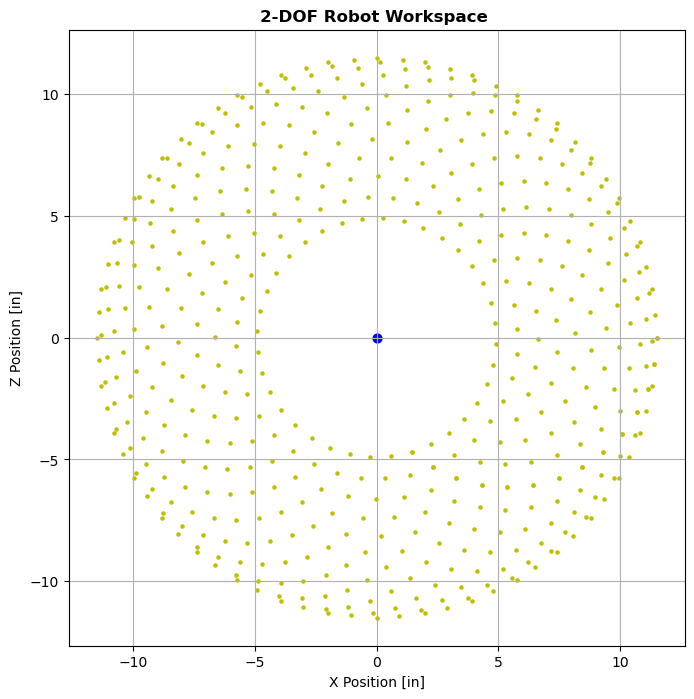

In [78]:
# ==========================
# Plot 2-DOF Workspace (Z–X Plane)
# ==========================
fig, ax = plt.subplots(figsize=(8, 8))

# X vs Z
ax.scatter(all_points2[:,0], all_points2[:,2],
           c='y', s=5, label='2-DOF Workspace')

# Origin
ax.scatter(0, 0, c='b', s=40, marker='o')

ax.set_xlabel('X Position [in]')
ax.set_ylabel('Z Position [in]')
ax.set_title('2-DOF Robot Workspace ',fontsize=12, fontweight='bold')

ax.set_aspect('equal', adjustable='box')
ax.grid(True)


plt.show()


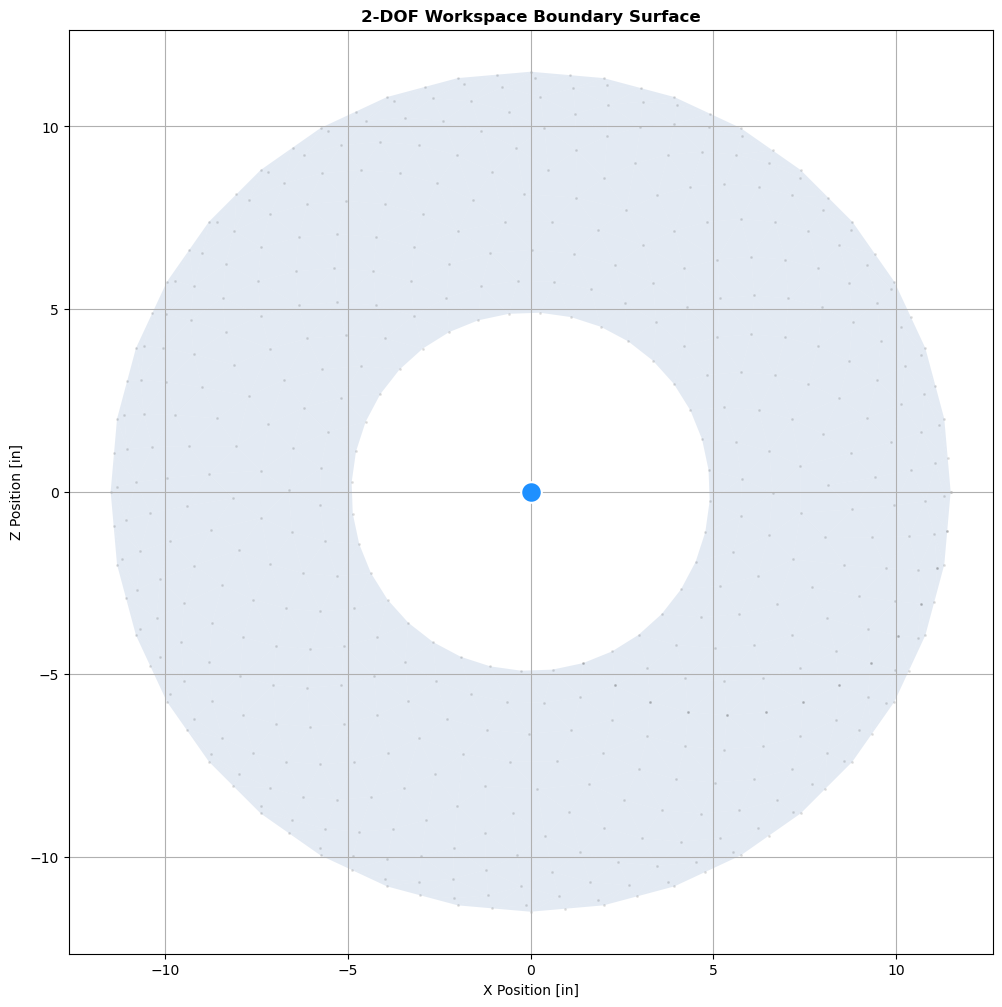

Kept boundary triangles: 900
Tip: lower factor for more detail, higher factor for smoother boundary.


In [89]:
# ==========================
# Reconstruct and plot 2-DOF boundary (X-Z alpha-shape)
# ==========================
from matplotlib.collections import PolyCollection

def _tri_circumradius(tri_pts):
    p0, p1, p2 = tri_pts
    a = np.linalg.norm(p1 - p0)
    b = np.linalg.norm(p2 - p1)
    c = np.linalg.norm(p0 - p2)
    s = 0.5 * (a + b + c)
    area_sq = s * (s - a) * (s - b) * (s - c)
    if area_sq <= 1e-14:
        return np.inf
    area = np.sqrt(area_sq)
    return (a * b * c) / (4.0 * area)

def alpha_shape_2d(points_xz, alpha):
    """Return kept Delaunay triangles for 2D alpha-shape."""
    tri = Delaunay(points_xz)
    simplices = tri.simplices

    keep = []
    for i, t in enumerate(simplices):
        r = _tri_circumradius(points_xz[t])
        if r < alpha:
            keep.append(i)

    if not keep:
        raise ValueError('No triangles kept. Increase alpha2.')

    return points_xz, simplices[np.array(keep)]

points_xz = all_points2[:, [0, 2]]
alpha2 = estimate_alpha(points_xz, k=8, factor=1.6)
verts2, tris2 = alpha_shape_2d(points_xz, alpha2)

fig, ax = plt.subplots(figsize=(12, 12))

poly = PolyCollection(
    verts2[tris2],
    facecolor='lightsteelblue',
    edgecolor='none',
    alpha=0.35
)
ax.add_collection(poly)

# Optional: lightly overlay raw samples
ax.scatter(points_xz[:, 0], points_xz[:, 1], s=1.5, c='k', alpha=0.08)

# Origin marker
ax.scatter(0, 0, c='dodgerblue', s=220, marker='o', edgecolors='white', linewidths=1.5, label='Origin', zorder=10)
# ax.text(0, 0, '  Origin', color='dodgerblue', fontsize=10)

ax.set_xlabel('X Position [in]')
ax.set_ylabel('Z Position [in]')
ax.set_title(f'2-DOF Workspace Boundary Surface', fontsize=12, fontweight='semibold')
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
# ax.legend(loc='upper right')
ax.autoscale_view()

plt.show()

print(f'Kept boundary triangles: {len(tris2)}')
print('Tip: lower factor for more detail, higher factor for smoother boundary.')


In [79]:
def compute_reach(points_xyz):
    r = np.linalg.norm(points_xyz, axis=1)   # sqrt(x^2+y^2+z^2)
    return r.max()

def compute_reach_xz(points_xyz):
    xz = points_xyz[:, [0, 2]]
    r = np.linalg.norm(xz, axis=1)
    return r.max()

def convex_hull_volume(points_xyz):
    from scipy.spatial import ConvexHull
    hull = ConvexHull(points_xyz)
    return hull.volume

from scipy.spatial import ConvexHull

def workspace_area_xz(points_xyz):
    xz = points_xyz[:, [0, 2]]   # drop Y
    hull = ConvexHull(xz)
    return hull.area


In [80]:
area_3dof = workspace_area_xz(all_points)
area_2dof = workspace_area_xz(all_points2)

print("\n=== WORKSPACE AREA (XZ PLANE) ===")
print(f"3-DOF workspace area: {area_3dof:.4f}")
print(f"2-DOF workspace area: {area_2dof:.4f}")

print("\n=== AREA RATIO ===")
print(f"3-DOF / 2-DOF area ratio: {area_3dof / area_2dof:.3f}")



=== WORKSPACE AREA (XZ PLANE) ===
3-DOF workspace area: 79.0638
2-DOF workspace area: 72.1461

=== AREA RATIO ===
3-DOF / 2-DOF area ratio: 1.096
